Este notebook tiene como objetivo generar las imágenes a utilizar en el artículo de emb2dis.

In [1]:
import sys
import requests
import numpy as np
import pandas as pd
import torch as tr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

sys.path.append("..")
from src.model import BaseModel
from src.utils import ConfigLoader, predict_sliding_window

from Bio.PDB import PDBParser
from matplotlib import gridspec

# Funciones

In [2]:
def get_plddt_from_alphafold(uniprot_id, cache_dir="../data/processed/plddt_cache", force_refresh=False):
    """
    Obtiene los valores de pLDDT para cada residuo a partir de AlphaFold.

    - Si existe cache local para `uniprot_id`, lo carga desde disco.
    - Si no existe (o force_refresh=True), consulta la API, guarda el cache y retorna.
    """
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_file = cache_dir / f"{uniprot_id}_plddt.csv"

    # 1) Intentar cargar cache local
    if cache_file.exists() and not force_refresh:
        try:
            cached_df = pd.read_csv(cache_file)
            if {"residue", "plddt"}.issubset(cached_df.columns):
                return list(zip(cached_df["residue"].astype(int), cached_df["plddt"].astype(float)))
            else:
                print(f"Cache inválido para {uniprot_id}, se volverá a descargar.")
        except Exception as e:
            print(f"No se pudo leer cache para {uniprot_id}: {e}. Se volverá a descargar.")

    headers = {"User-Agent": "emb2dis/1.0"}

    # 2) Consultar API para obtener URL del PDB
    api_url = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}"
    response = requests.get(api_url, headers=headers, timeout=30)
    response.raise_for_status()

    try:
        data = response.json()
    except ValueError as exc:
        preview = response.text[:200].replace("\n", " ")
        raise RuntimeError(
            f"AlphaFold API no devolvió JSON válido para {uniprot_id}. "
            f"Status={response.status_code}, body='{preview}'"
        ) from exc

    if not isinstance(data, list) or len(data) == 0:
        raise RuntimeError(f"No hay predicción AlphaFold para {uniprot_id}.")

    pdb_url = data[0].get("pdbUrl")
    if not pdb_url:
        raise RuntimeError(f"La respuesta de AlphaFold no incluye 'pdbUrl' para {uniprot_id}.")

    # 3) Descargar PDB y extraer pLDDT
    pdb_response = requests.get(pdb_url, headers=headers, timeout=60)
    pdb_response.raise_for_status()
    pdb_content = pdb_response.text

    plddt_values = []
    for line in pdb_content.split('\n'):
        if line.startswith('ATOM') and line[12:16].strip() == 'CA':  # solo Cα
            plddt = float(line[60:66].strip())  # columna B-factor
            residue = int(line[22:26].strip())
            plddt_values.append((residue, plddt))

    if len(plddt_values) == 0:
        raise RuntimeError(f"No se pudieron extraer valores pLDDT para {uniprot_id} desde el PDB.")

    # 4) Guardar cache local
    pd.DataFrame(plddt_values, columns=["residue", "plddt"]).to_csv(cache_file, index=False)
    print(f"pLDDT guardado en cache: {cache_file}")

    return plddt_values

# Uso
plddt = get_plddt_from_alphafold("P03934")
for residue, score in plddt[:10]:
    print(f"Residuo {residue:3d}: pLDDT = {score:.2f}")

Residuo   1: pLDDT = 64.88
Residuo   2: pLDDT = 80.06
Residuo   3: pLDDT = 87.38
Residuo   4: pLDDT = 90.00
Residuo   5: pLDDT = 90.25
Residuo   6: pLDDT = 91.31
Residuo   7: pLDDT = 92.56
Residuo   8: pLDDT = 90.94
Residuo   9: pLDDT = 91.12
Residuo  10: pLDDT = 91.75


In [3]:
colors = [
    "#FD3C35",  # 0   → very low
    "#FC6D2F",  # 0   → very low
    "#FF7D45",  # 0   → very low
    "#FFD900",  # 50  → low
    "#7BAFFF",  # 70  → high
    "#0053D6"   # 90+ → very high
]

# Crear un colormap continuo basado en esos puntos
af_cmap = LinearSegmentedColormap.from_list("af_plddt", colors)

In [31]:
from matplotlib.ticker import MultipleLocator
# FUNCION CON LAS COSAS CHIQUITAS

def get_domain_graphs_with_plddt(
        protein,
        results_path, # Path to model results directory (containing config.yaml and weights.pk)
        dataset, # Name of dataset CSV file (without extension)
        uniprot_id=None, # Optional UniProt ID (if different from protein name)
        title=None,
        save_pdf=False,
        output_dir="../notebooks/figures/",
        threshold=0.5,
        figsize=(8.25, 3.6),
        region_tracks=None
        ):
    """
    Función que genera gráficos de predicción de desorden junto con una barra
    de colores que representa los valores de pLDDT obtenidos de los archivos de
    AlphaFold para una única proteína.
    """
    # Paths y configuraciones --------------------------------------------------
    results_path = Path(results_path)
    output_dir = Path(output_dir)

    config_loader = ConfigLoader(model_path=results_path / 'config.yaml',
                                 env_path=Path("../config/env.yaml"))
    config = config_loader.load()
    softmax = config['soft_max']
    threshold = threshold

    if region_tracks is None:
        region_tracks = []

    def _parse_region(region):
        start, end, box_color, label = None, None, '#808080', None

        if isinstance(region, dict):
            start = region.get('start')
            end = region.get('end')
            box_color = region.get('color', '#808080')
            label = region.get('label')
        elif isinstance(region, (list, tuple)):
            if len(region) >= 2:
                start, end = region[0], region[1]
            if len(region) >= 3:
                box_color = region[2]
            if len(region) >= 4:
                label = region[3]

        if start is None or end is None:
            return None

        start = float(start)
        end = float(end)
        if end < start:
            start, end = end, start

        return start, end, box_color, label

    # Modelo ------------------------------------------------------------------
    device = 'cuda' if tr.cuda.is_available() else 'cpu'
    model = BaseModel(
        len(config['categories']),
        emb_size=config['emb_size'][config['pLM']],
        lr=config['lr'],
        p_dropout=config['p_dropout'],
        device=device,
        filters=config['filters'],
        kernel_size=config['kernel_size'],
        num_layers=config['n_resnet'])

    # Load weights with appropriate map_location if GPU not available
    state = tr.load(results_path / 'weights.pk', map_location=tr.device(device))
    model.load_state_dict(state)
    model.to(device)
    model.eval()

    # Load the data
    df = pd.read_csv(f"../{config['data_path']}{dataset}.csv")

    # Category colors
    category_colors = {
        "structured": "#0053D6",
        "disordered": "#FC6D2F"
    }

    PID = protein
    if uniprot_id is None:
        uniprot_id = PID

    # ===== Load and predict disorder =====
    emb = np.load(f"../{config['emb_path']}{config['pLM']}/{PID}.npy")
    emb = tr.tensor(emb, dtype=tr.float32)

    centers, pred = predict_sliding_window(model, emb, config['win_len'],
                                           step=1, use_softmax=softmax)

    # Get domains for this protein
    protein_domains = df[df.acc == PID].sort_values(by="start")

    # Load pLDDT via AlphaFold API (no PDB local)
    plddt_values = None
    try:
        fetched = get_plddt_from_alphafold(uniprot_id)
        if fetched and len(fetched) > 0:
            filtered = [(int(r), float(s)) for (r, s) in fetched if r is not None]
            if len(filtered) > 0:
                residues, _ = zip(*filtered)
                max_res = int(max(residues))
                arr = np.full(max_res, np.nan)
                for r, s in filtered:
                    if 1 <= int(r) <= max_res:
                        arr[int(r) - 1] = float(s)
                plddt_values = arr
            else:
                plddt_values = None
        else:
            plddt_values = None
    except Exception as e:
        print(f"Warning: Could not fetch pLDDT from AlphaFold API for {uniprot_id}: {e}")
        plddt_values = None

    # FIGURE ------------------------------------------------------------------
    n_region_tracks = len(region_tracks)
    n_rows = 3 + n_region_tracks
    height_ratios = [1.5, 0.3, 0.2] + [0.15] * n_region_tracks # ancho anterior 0.3
    hspace = 0.1

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(
        n_rows, 1,
        height_ratios=height_ratios,
        hspace=hspace
    )

    # ----- Panel 1: Disorder score -------------------------------------------
    ax1 = fig.add_subplot(gs[0, 0])

    color = category_colors.get('disordered', "red")
    ax1.plot(centers, pred[:, 1], "-", color=color, linewidth=1.5, label='Disorder')
    
    # Add domain regions
    if len(protein_domains.shape) == 1:
        domains_list = [protein_domains]
    else:
        domains_list = [protein_domains.iloc[k] for k in range(len(protein_domains))]

    for domain in domains_list:
        color = category_colors.get(domain.label, "gray")
        ax1.axvspan(domain.start, domain.end, ymin=0, ymax=1, alpha=0.2, color=color)

    ax1.axhline(y=threshold, color='gray', linestyle='--', linewidth=1)
    ax1.set_xlim([centers.min(), centers.max()])
    ax1.set_ylim([-0.05, 1.05])
    ax1.set_ylabel("Disorder score")
    ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    # ax1.grid(alpha=0.3)

    ax1.set_xlabel("Amino acids")
    ax1.tick_params(axis='x', which='both', bottom=True, labelbottom=True)

    # ----- Empty gap row ------------------------------------------------------
    ax_gap = fig.add_subplot(gs[1, 0], sharex=ax1)
    ax_gap.axis('off')

    # ----- Panel 2: pLDDT color bar -------------------------------------------
    ax2 = fig.add_subplot(gs[2, 0], sharex=ax1)

    if plddt_values is not None and len(plddt_values) > 0:
        plddt_norm = plddt_values / 100.0
        plddt_row = plddt_norm[np.newaxis, :]
        ax2.imshow(
            plddt_row,
            aspect="auto",
            origin="lower",
            extent=[1, len(plddt_values), 0, 1],
            cmap=af_cmap,  # Red-Yellow-Green (low to high confidence)
            vmin=0,  # Force minimum value to 0
            vmax=1   # Force maximum value to 1
        )
        ax2.set_yticks([])
        ax2.set_ylabel("pLDDT", rotation=0, labelpad=20, va='center')

        ax2.set_xlim([centers.min(), centers.max()])

    else:
        ax2.text(0.5, 0.5, f"No pLDDT data available",
                ha='center', va='center', fontsize=10, color='gray',
                transform=ax2.transAxes)
        ax2.set_xlim([centers.min(), centers.max()])
        ax2.set_xlabel("Amino acids", fontsize=11)
        ax2.set_yticks([])

    # ----- Dynamic region tracks ----------------------------------------------
    region_axes = []
    for i, track in enumerate(region_tracks, start=1):
        row_idx = 2 + i
        ax_track = fig.add_subplot(gs[row_idx, 0], sharex=ax1)
        ax_track.hlines(0.5, centers.min(), centers.max(), color='black', linewidth=1.5)

        track_label = f"Regions {i}"
        regions = track
        if isinstance(track, dict):
            track_label = track.get('label', track_label)
            regions = track.get('regions', [])

        for region in regions:
            parsed = _parse_region(region)
            if parsed is None:
                continue
            start, end, box_color, label = parsed
            ax_track.axvspan(start, end, ymin=0.2, ymax=0.8, alpha=1, facecolor=box_color, edgecolor='black', linewidth=0.5, zorder=2) #0.15,0.85

            if label:
                x_center = (start + end) / 2.0
                ax_track.text(x_center, 0.5, str(label), ha='center', va='center', fontsize=8, color='white')

        for spine in ax_track.spines.values():
            spine.set_visible(False)

        ax_track.set_ylim([0, 1])
        ax_track.set_yticks([])
        ax_track.set_ylabel(track_label, rotation=0, labelpad=20, va='center')
        ax_track.set_xlim([centers.min(), centers.max()])
        ax_track.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
        region_axes.append(ax_track)

    # X labels and ticks
    if len(region_axes) > 0:
        pass
        ax2.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
        # region_axes[-1].set_xlabel("Amino acids")
        # region_axes[-1].tick_params(axis='x', which='both', bottom=True, labelbottom=True)
    else:
        ax2.set_xlabel("Amino acids")
        ax2.tick_params(axis='x', which='both', bottom=True, labelbottom=True)

    for axis in [ax1, ax2] + region_axes:
        axis.xaxis.set_major_locator(MultipleLocator(50))

    # Save as PDF if requested
    if save_pdf:
        pdf_filename = output_dir / f"{PID}_disorder_plddt_ang.pdf"
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight', dpi=300)
        print(f"Saved: {pdf_filename.name}")

    plt.show()

    print(f"Plotted: {PID}")
    print()

In [31]:
from matplotlib.ticker import MultipleLocator


def get_domain_graphs_with_plddt(
        protein,
        results_path, # Path to model results directory (containing config.yaml and weights.pk)
        dataset, # Name of dataset CSV file (without extension)
        uniprot_id=None, # Optional UniProt ID (if different from protein name)
        title=None,
        save_pdf=False,
        output_dir="../notebooks/figures/",
        threshold=0.5,
        figsize=(8.25, 3.6),
        region_tracks=None
        ):
    """
    Función que genera gráficos de predicción de desorden junto con una barra
    de colores que representa los valores de pLDDT obtenidos de los archivos de
    AlphaFold para una única proteína.
    """
    # Paths y configuraciones --------------------------------------------------
    results_path = Path(results_path)
    output_dir = Path(output_dir)

    config_loader = ConfigLoader(model_path=results_path / 'config.yaml',
                                 env_path=Path("../config/env.yaml"))
    config = config_loader.load()
    softmax = config['soft_max']
    threshold = threshold

    if region_tracks is None:
        region_tracks = []

    def _parse_region(region):
        start, end, box_color, label = None, None, '#808080', None

        if isinstance(region, dict):
            start = region.get('start')
            end = region.get('end')
            box_color = region.get('color', '#808080')
            label = region.get('label')
        elif isinstance(region, (list, tuple)):
            if len(region) >= 2:
                start, end = region[0], region[1]
            if len(region) >= 3:
                box_color = region[2]
            if len(region) >= 4:
                label = region[3]

        if start is None or end is None:
            return None

        start = float(start)
        end = float(end)
        if end < start:
            start, end = end, start

        return start, end, box_color, label

    # Modelo ------------------------------------------------------------------
    device = 'cuda' if tr.cuda.is_available() else 'cpu'
    model = BaseModel(
        len(config['categories']),
        emb_size=config['emb_size'][config['pLM']],
        lr=config['lr'],
        p_dropout=config['p_dropout'],
        device=device,
        filters=config['filters'],
        kernel_size=config['kernel_size'],
        num_layers=config['n_resnet'])

    # Load weights with appropriate map_location if GPU not available
    state = tr.load(results_path / 'weights.pk', map_location=tr.device(device))
    model.load_state_dict(state)
    model.to(device)
    model.eval()

    # Load the data
    df = pd.read_csv(f"../{config['data_path']}{dataset}.csv")

    # Category colors
    category_colors = {
        "structured": "#0053D6",
        "disordered": "#FC6D2F"
    }

    PID = protein
    if uniprot_id is None:
        uniprot_id = PID

    # ===== Load and predict disorder =====
    emb = np.load(f"../{config['emb_path']}{config['pLM']}/{PID}.npy")
    emb = tr.tensor(emb, dtype=tr.float32)

    centers, pred = predict_sliding_window(model, emb, config['win_len'],
                                           step=1, use_softmax=softmax)

    # Get domains for this protein
    protein_domains = df[df.acc == PID].sort_values(by="start")

    # Load pLDDT via AlphaFold API (no PDB local)
    plddt_values = None
    try:
        fetched = get_plddt_from_alphafold(uniprot_id)
        if fetched and len(fetched) > 0:
            filtered = [(int(r), float(s)) for (r, s) in fetched if r is not None]
            if len(filtered) > 0:
                residues, _ = zip(*filtered)
                max_res = int(max(residues))
                arr = np.full(max_res, np.nan)
                for r, s in filtered:
                    if 1 <= int(r) <= max_res:
                        arr[int(r) - 1] = float(s)
                plddt_values = arr
            else:
                plddt_values = None
        else:
            plddt_values = None
    except Exception as e:
        print(f"Warning: Could not fetch pLDDT from AlphaFold API for {uniprot_id}: {e}")
        plddt_values = None

    # FIGURE ------------------------------------------------------------------
    n_region_tracks = len(region_tracks)
    n_rows = 3 + n_region_tracks
    height_ratios = [1.5, 0.3, 0.2] + [0.2] * n_region_tracks # ancho anterior 0.3
    hspace = 0.1# 0.5 if n_region_tracks <= 2 else 0.1

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(
        n_rows, 1,
        height_ratios=height_ratios,
        hspace=hspace
    )

    # ----- Panel 1: Disorder score -------------------------------------------
    ax1 = fig.add_subplot(gs[0, 0])

    color = category_colors.get('disordered', "red")
    ax1.plot(centers, pred[:, 1], "-", color=color, linewidth=1.5, label='Disorder')
    
    # Add domain regions
    if len(protein_domains.shape) == 1:
        domains_list = [protein_domains]
    else:
        domains_list = [protein_domains.iloc[k] for k in range(len(protein_domains))]

    for domain in domains_list:
        color = category_colors.get(domain.label, "gray")
        ax1.axvspan(domain.start, domain.end, ymin=0, ymax=1, alpha=0.2, color=color)

    ax1.axhline(y=threshold, color='gray', linestyle='--', linewidth=1)
    ax1.set_xlim([centers.min(), centers.max()])
    ax1.set_ylim([-0.05, 1.05])
    ax1.set_ylabel("Disorder score")
    ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax1.grid(alpha=0.2)

    if title:
        ax1.set_title(title)
    else:
        ax1.set_title(f"Protein {PID}")
    ax1.set_xlabel("Amino acids")
    ax1.tick_params(axis='x', which='both', bottom=True, labelbottom=True)

    # ----- Empty gap row ------------------------------------------------------
    ax_gap = fig.add_subplot(gs[1, 0], sharex=ax1)
    ax_gap.axis('off')

    # ----- Panel 2: pLDDT color bar -------------------------------------------
    ax2 = fig.add_subplot(gs[2, 0], sharex=ax1)

    if plddt_values is not None and len(plddt_values) > 0:
        plddt_norm = plddt_values / 100.0
        plddt_row = plddt_norm[np.newaxis, :]
        ax2.imshow(
            plddt_row,
            aspect="auto",
            origin="lower",
            extent=[1, len(plddt_values), 0, 1],
            cmap=af_cmap,  # Red-Yellow-Green (low to high confidence)
            vmin=0,  # Force minimum value to 0
            vmax=1   # Force maximum value to 1
        )
        ax2.set_yticks([])
        ax2.set_ylabel("pLDDT", rotation=0, labelpad=20, va='center')

        ax2.set_xlim([centers.min(), centers.max()])

    else:
        ax2.text(0.5, 0.5, f"No pLDDT data available",
                ha='center', va='center', fontsize=10, color='gray',
                transform=ax2.transAxes)
        ax2.set_xlim([centers.min(), centers.max()])
        ax2.set_xlabel("Amino acids", fontsize=11)
        ax2.set_yticks([])

    # ----- Dynamic region tracks ----------------------------------------------
    region_axes = []
    for i, track in enumerate(region_tracks, start=1):
        row_idx = 2 + i
        ax_track = fig.add_subplot(gs[row_idx, 0], sharex=ax1)
        ax_track.hlines(0.5, centers.min(), centers.max(), color='black', linewidth=1.5)

        track_label = f"Regions {i}"
        regions = track
        if isinstance(track, dict):
            track_label = track.get('label', track_label)
            regions = track.get('regions', [])

        for region in regions:
            parsed = _parse_region(region)
            if parsed is None:
                continue
            start, end, box_color, label = parsed
            ax_track.axvspan(start, end, ymin=0.15, ymax=0.85, alpha=1, facecolor=box_color, edgecolor='black', linewidth=0.5, zorder=2) #0.15,0.85

            if label:
                x_center = (start + end) / 2.0
                ax_track.text(x_center, 0.5, str(label), ha='center', va='center', fontsize=8, color='black')

        for spine in ax_track.spines.values():
            spine.set_visible(False)

        ax_track.set_ylim([0, 1])
        ax_track.set_yticks([])
        ax_track.set_ylabel(track_label, rotation=0, labelpad=20, va='center')
        ax_track.set_xlim([centers.min(), centers.max()])
        ax_track.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
        region_axes.append(ax_track)

    # X labels and ticks
    if len(region_axes) > 0:
        pass
        ax2.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
        # region_axes[-1].set_xlabel("Amino acids")
        # region_axes[-1].tick_params(axis='x', which='both', bottom=True, labelbottom=True)
    else:
        ax2.set_xlabel("Amino acids")
        ax2.tick_params(axis='x', which='both', bottom=True, labelbottom=True)

    for axis in [ax1, ax2] + region_axes:
        axis.xaxis.set_major_locator(MultipleLocator(25))

    # Save as PDF if requested
    if save_pdf:
        pdf_filename = output_dir / f"{PID}_disorder_plddt_with_ref_FINAL.pdf"
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight', dpi=300)
        print(f"Saved: {pdf_filename.name}")

    plt.show()

    print(f"Plotted: {PID}")
    print()

# Probamos funcionamiento

In [45]:
c = {
    "missing": "#e77dc7ff",
    "missing_context_dependent": "#C04DBC",
    "structured": "#4C93FF",
    "disordered": "#FF7D45",
    "extracel": "#0bc694ff",
    "cytoplasmic": "#9d7acdff",
    "transmembrane": "#989898ff",
    "pfam": "#989898ff",
}

Saved: P10912_disorder_plddt_with_ref_FINAL.pdf


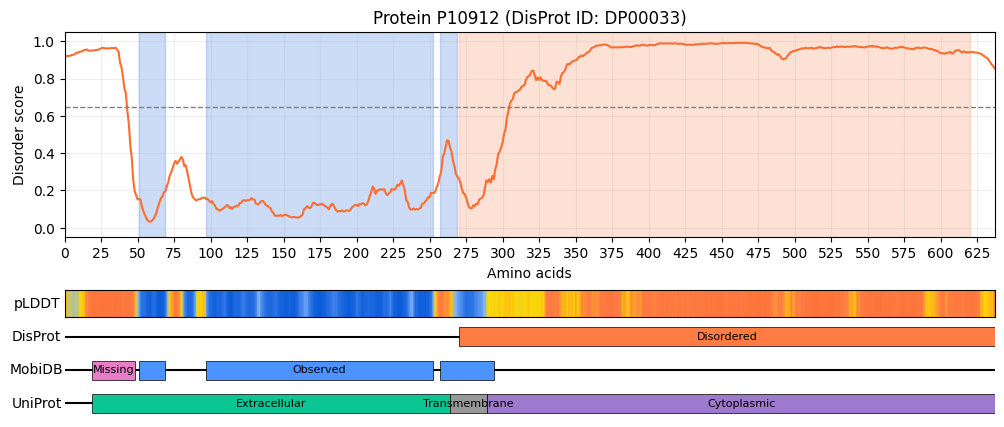

Plotted: P10912



In [55]:
id = "P10912"
results_path = Path("../model/ESM2/model0/")

# Múltiples pistas/paneles de regiones
custom_region_tracks = [
    {
        "label": "DisProt",
        "regions": [
            (270, 638, c['disordered'], "Disordered"),
        ]
    },
    {
        "label": "MobiDB",
        "regions": [
            (19, 48, c['missing'], "Missing"), # missing
            (51, 69, c['structured'], ""), # structured
            (97, 252, c['structured'], "Observed"), # structured
            (257, 294, c['structured'], "") # structured
        ]
    },
    {
        "label": "UniProt",
        "regions": [
            (19, 264, c['extracel'], "Extracellular"), #
            (264, 289, c['transmembrane'], "Transmembrane"),
            (289, 638, c['cytoplasmic'], "Cytoplasmic") #,
        ]
    },
]

dataset = 'train'

protein = {
    'disprot_id': id,
    'uniprot_id': id
}


get_domain_graphs_with_plddt(protein=protein["disprot_id"],
                                results_path=results_path,
                                dataset=dataset,
                                uniprot_id=protein['uniprot_id'],
                                title=f"Protein {protein['uniprot_id']} (DisProt ID: DP00033)",
                                save_pdf=True,
                            #  output_dir="./disorder_plddt_test_plots",
                                threshold=0.646,
                                figsize=(12, 5),
                                region_tracks=custom_region_tracks
                                )

Saved: DP04167_disorder_plddt_with_ref_FINAL.pdf


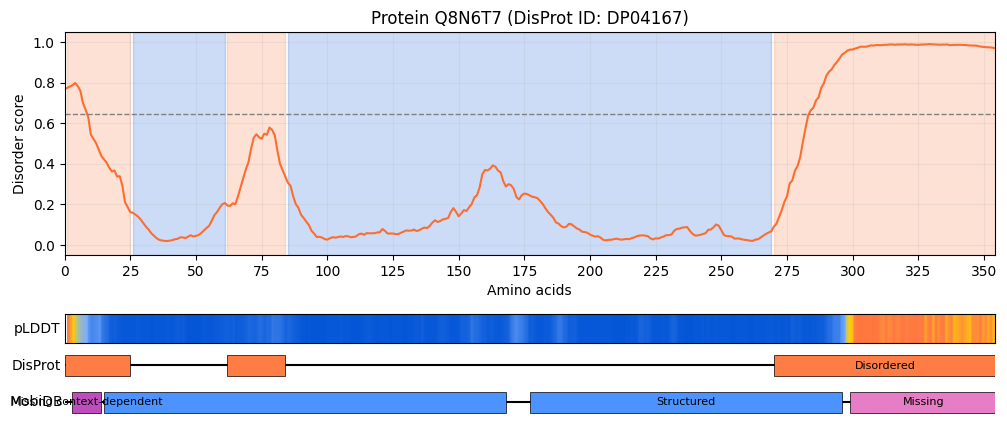

Plotted: DP04167



In [53]:
id = "DP04167"
dataset = 'caid3_3/disorder_pdb'
protein = {
    'disprot_id': id,
    'uniprot_id': "Q8N6T7"
}


# Múltiples pistas/paneles de regiones
custom_region_tracks = [
    {
        "label": "DisProt",
        "regions": [
            (0, 25, c['disordered'], ""),
            (62, 84,c['disordered'], ""),
            (270, 355,c['disordered'], "Disordered"),
        ]
    },
    {
        "label": "MobiDB",
        "regions": [
            (3, 14, c['missing_context_dependent'], "Missing context-dependent"), # missing_context_dependent
            (15, 168, c['structured'], ""),
            (177, 296, c['structured'], "Structured"),
            (299, 355, c['missing'], "Missing")
        ]
    }
]


try:
    get_domain_graphs_with_plddt(protein=protein["disprot_id"],
                                 results_path=results_path,
                                 dataset=dataset,
                                 uniprot_id=protein['uniprot_id'],
                                 title=f"Protein {protein['uniprot_id']} (DisProt ID: DP04167)",
                                 save_pdf=True,
                                 threshold=0.646,
                                 figsize=(12, 5),
                                 region_tracks=custom_region_tracks
                                 )
except Exception as e:
    print("Error al ejecutar get_domain_graphs_with_plddt:", e)



Saved: DP04240_disorder_plddt_with_ref_FINAL.pdf


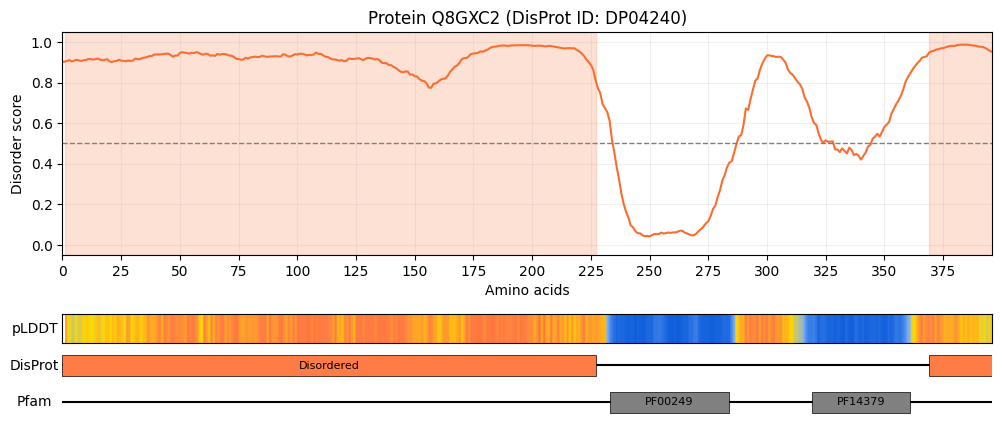

Plotted: DP04240



In [ ]:
id = "DP04240"
dataset = 'caid3_3/disorder_pdb'
protein = {
    'disprot_id': id,
    'uniprot_id': "Q8GXC2"
}

# Múltiples pistas/paneles de regiones
custom_region_tracks = [
    {
        "label": "DisProt",
        "regions": [
            (0, 227, c['disordered'], "Disordered"),
            (369, 397,c['disordered'], ""),
        ]
    },
    {
        "label": "Pfam",
        "regions": [
            (233, 284, "gray", "PF00249"),
            (319, 361, "gray", "PF14379")
        ]
    },
]


get_domain_graphs_with_plddt(protein=protein["disprot_id"],
                                results_path=results_path,
                                dataset=dataset,
                                uniprot_id=protein['uniprot_id'],
                                title=f"Protein {protein['uniprot_id']} (DisProt ID: DP04240)",
                                save_pdf=True,
                                threshold=0.646,
                                figsize=(12, 5),
                                region_tracks=custom_region_tracks
                                )